In [84]:
import diplib as dip
import numpy as np
import matplotlib.pyplot as plt
import os

In [85]:
os.makedirs('output', exist_ok=True)

# Series A filenames
filenames_a = {
    'rect1a': 'rect1a.tif',
    'rect2a': 'rect2a.tif',
    'rect3a': 'rect3a.tif',
    'rect4a': 'rect4a.tif',
}

series_a = {name: dip.ImageRead(fname) for name, fname in filenames_a.items()}


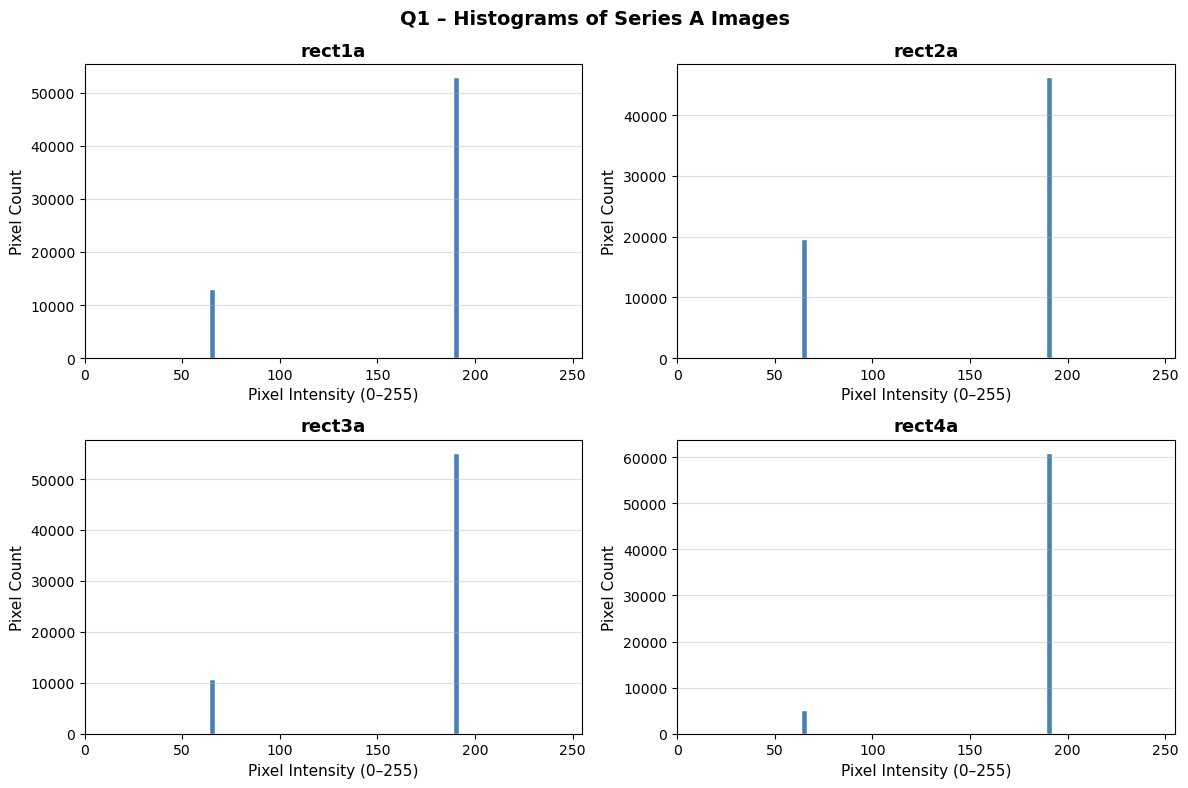

In [86]:
################################
# Q1: Histograms of Series A
################################

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, name in enumerate(sorted(series_a)):
    arr = np.array(series_a[name]).flatten()
    axes[idx].hist(arr, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[idx].set_title(name, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Pixel Intensity (0–255)', fontsize=11)
    axes[idx].set_ylabel('Pixel Count', fontsize=11)
    axes[idx].set_xlim(0, 255)
    axes[idx].grid(axis='y', alpha=0.4)

fig.suptitle('Q1 – Histograms of Series A Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/q1_histograms_seriesA.png', bbox_inches='tight')
plt.show()


In [87]:
##############################################
# Q2: Measure area of each object per image
###############################################
results = {}

for name in sorted(series_a):
    img = series_a[name]

    # Threshold: IsodataThreshold returns a binary image
    bin_img = ~dip.IsodataThreshold(img)

    # Label connected components and measure areas
    labeled = dip.Label(bin_img, minSize=50)
    msr = dip.MeasurementTool.Measure(labeled, img, ['Size'])
    areas = [msr[obj]['Size'][0] for obj in msr.Objects()]

    mean_area = np.mean(areas)
    std_area  = np.std(areas, ddof=1)

    results[name] = {'areas': areas, 'mean': mean_area, 'std': std_area, 'n': len(areas)}

    print(f"\n{name}:")
    print(f"  Individual areas (px²): {[round(a, 1) for a in areas]}")
    print(f"  Mean area : {mean_area:.2f} px²")
    print(f"  Std dev   : {std_area:.2f} px²")

# Summary table
print("\n── Q2 Summary Table ──────────────────────────────")
print(f"{'Image':<10} {'N objects':>10} {'Mean Area (px²)':>16} {'Std Dev (px²)':>14}")
print("-" * 54)
for name in sorted(results):
    r = results[name]
    print(f"{name:<10} {len(r['areas']):>10} {r['mean']:>16.2f} {r['std']:>14.2f}")


rect1a:
  Individual areas (px²): [12848.0]
  Mean area : 12848.00 px²
  Std dev   : nan px²

rect2a:
  Individual areas (px²): [3195.0, 3285.0, 3265.0, 3248.0, 3230.0, 3262.0]
  Mean area : 3247.50 px²
  Std dev   : 31.58 px²

rect3a:
  Individual areas (px²): [1320.0, 1328.0, 1335.0, 1304.0, 1340.0, 1309.0, 1297.0, 1360.0]
  Mean area : 1324.12 px²
  Std dev   : 20.90 px²

rect4a:
  Individual areas (px²): [475.0, 480.0, 480.0, 480.0, 486.0, 473.0, 468.0, 499.0, 484.0, 505.0]
  Mean area : 483.00 px²
  Std dev   : 11.38 px²

── Q2 Summary Table ──────────────────────────────
Image       N objects  Mean Area (px²)  Std Dev (px²)
------------------------------------------------------
rect1a              1         12848.00            nan
rect2a              6          3247.50          31.58
rect3a              8          1324.12          20.90
rect4a             10           483.00          11.38


c:\Users\ivanb\anaconda3\envs\rl_course\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ivanb\anaconda3\envs\rl_course\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [88]:
###################################################
# Q3: Measure perimeter of each object per image
####################################################
results_perim = {}

for name in sorted(series_a):
    img = series_a[name]

    # Same thresholding and labeling as Q2
    bin_img = ~dip.IsodataThreshold(img)
    labeled = dip.Label(bin_img, minSize=50)

    # Measure both Size and Perimeter in one call
    msr = dip.MeasurementTool.Measure(labeled, img, ['Size', 'Perimeter'])
    perims = [msr[obj]['Perimeter'][0] for obj in msr.Objects()]

    mean_p = np.mean(perims)
    std_p  = np.std(perims, ddof=1)

    results_perim[name] = {'n': len(perims), 'perims': perims,
                           'mean': mean_p, 'std': std_p}

    print(f"\n{name}:")
    print(f"  Individual perimeters (px): {[round(p, 1) for p in perims]}")
    print(f"  Mean perimeter : {mean_p:.2f} px")
    print(f"  Std dev        : {std_p:.2f} px")

# Summary table
print(f"\n{'Image':<10} {'N':>5} {'Mean Perimeter (px)':>20} {'Std Dev (px)':>14}")
print("-" * 54)
for name in sorted(results_perim):
    r = results_perim[name]
    std_str = f"{r['std']:>14.2f}" if r['n'] > 1 else "           N/A"
    print(f"{name:<10} {r['n']:>5} {r['mean']:>20.2f} {std_str}")


rect1a:
  Individual perimeters (px): [457.5]
  Mean perimeter : 457.50 px
  Std dev        : nan px

rect2a:
  Individual perimeters (px): [233.7, 230.1, 234.7, 236.0, 233.3, 235.1]
  Mean perimeter : 233.81 px
  Std dev        : 2.04 px

rect3a:
  Individual perimeters (px): [143.9, 148.8, 148.9, 146.9, 147.0, 147.5, 147.2, 150.5]
  Mean perimeter : 147.58 px
  Std dev        : 1.92 px

rect4a:
  Individual perimeters (px): [92.4, 91.0, 91.0, 92.9, 93.4, 92.0, 92.7, 93.5, 94.1, 95.2]
  Mean perimeter : 92.82 px
  Std dev        : 1.32 px

Image          N  Mean Perimeter (px)   Std Dev (px)
------------------------------------------------------
rect1a         1               457.50            N/A
rect2a         6               233.81           2.04
rect3a         8               147.58           1.92
rect4a        10                92.82           1.32


In [89]:
print(f"{'Image':<10} {'Object':>8} {'Area (px²)':>12} {'Perimeter (px)':>16}")
print("=" * 52)

for name in sorted(results):
    r_area = results[name]
    r_perim = results_perim[name]

    # One row per rectangle
    for i, (area, perim) in enumerate(zip(r_area['areas'], r_perim['perims'])):
        print(f"{name:<10} {i+1:>8} {area:>12.1f} {perim:>16.1f}")

    # Summary rows per image
    std_a = r_area['std']  if r_area['n'] > 1 else 0.0
    std_p = r_perim['std'] if r_perim['n'] > 1 else 0.0
    print(f"{'':10} {'Mean':>8} {r_area['mean']:>12.2f} {r_perim['mean']:>16.2f}")
    print(f"{'':10} {'Std Dev':>8} {std_a:>12.2f} {std_p:>16.2f}")
    print("-" * 52)

Image        Object   Area (px²)   Perimeter (px)
rect1a            1      12848.0            457.5
               Mean     12848.00           457.50
            Std Dev         0.00             0.00
----------------------------------------------------
rect2a            1       3195.0            233.7
rect2a            2       3285.0            230.1
rect2a            3       3265.0            234.7
rect2a            4       3248.0            236.0
rect2a            5       3230.0            233.3
rect2a            6       3262.0            235.1
               Mean      3247.50           233.81
            Std Dev        31.58             2.04
----------------------------------------------------
rect3a            1       1320.0            143.9
rect3a            2       1328.0            148.8
rect3a            3       1335.0            148.9
rect3a            4       1304.0            146.9
rect3a            5       1340.0            147.0
rect3a            6       1309.0            


── Q4: Area – Relative Discretization Error ───────────────
Image         Mean Area    Std Dev   √Mean Area     CV (σ/μ)
------------------------------------------------------------
rect2a          3247.50      31.58      56.9868       0.0097
rect3a          1324.12      20.90      36.3885       0.0158
rect4a           483.00      11.38      21.9773       0.0236


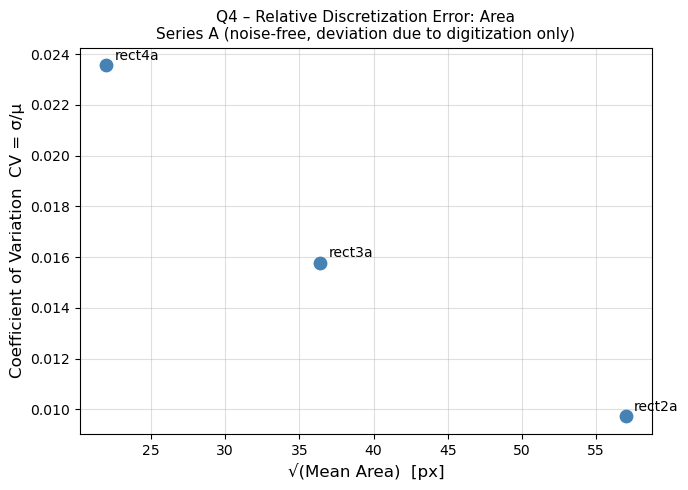

In [90]:
##############################################
# Q4: Relative discretization error – Area
##############################################

# Only use images with more than 1 object (need std dev)
names_valid = [n for n in sorted(results) if results[n]['n'] > 1]

sqrt_mean_area = [np.sqrt(results[n]['mean']) for n in names_valid]
cv_area        = [results[n]['std'] / results[n]['mean'] for n in names_valid]

# Print table
print("\n── Q4: Area – Relative Discretization Error ───────────────")
print(f"{'Image':<10} {'Mean Area':>12} {'Std Dev':>10} {'√Mean Area':>12} {'CV (σ/μ)':>12}")
print("-" * 60)
for n in names_valid:
    r = results[n]
    print(f"{n:<10} {r['mean']:>12.2f} {r['std']:>10.2f} "
          f"{np.sqrt(r['mean']):>12.4f} "
          f"{r['std']/r['mean']:>12.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sqrt_mean_area, cv_area, color='steelblue', s=80, zorder=3)
for i, n in enumerate(names_valid):
    ax.annotate(n, (sqrt_mean_area[i], cv_area[i]),
                textcoords='offset points', xytext=(6, 4), fontsize=10)

ax.set_xlabel('√(Mean Area)  [px]', fontsize=12)
ax.set_ylabel('Coefficient of Variation  CV = σ/μ', fontsize=12)
ax.set_title('Q4 – Relative Discretization Error: Area\n'
             'Series A (noise-free, deviation due to digitization only)', fontsize=11)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('output/q4_discretization_area.png', bbox_inches='tight')
plt.show()


── Q5: Perimeter – Relative Discretization Error ──────────
Image        Mean Perim    Std Dev   √Mean Perim     CV (σ/μ)
--------------------------------------------------------------
rect2a           233.81       2.04       15.2909       0.0087
rect3a           147.58       1.92       12.1483       0.0130
rect4a            92.82       1.32        9.6345       0.0143


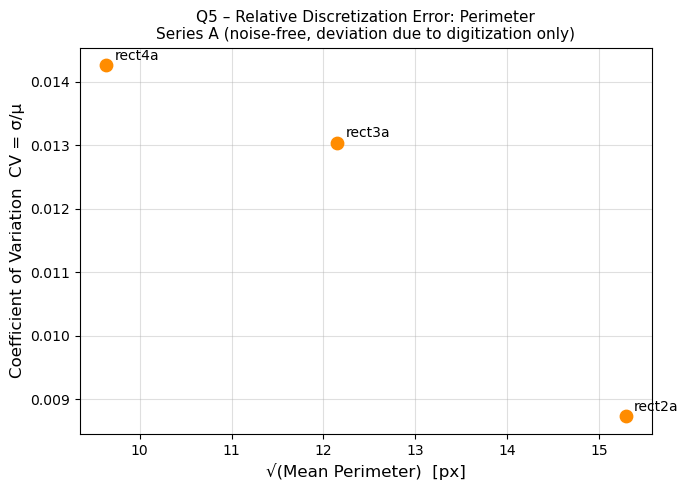

In [91]:
##############################################
# Q5: Relative discretization error – Perimeter
##############################################

# Only use images with more than 1 object (need std dev)
names_valid = [n for n in sorted(results_perim) if results_perim[n]['n'] > 1]

sqrt_mean_perim = [np.sqrt(results_perim[n]['mean']) for n in names_valid]
cv_perim        = [results_perim[n]['std'] / results_perim[n]['mean'] for n in names_valid]

# Print table
print("\n── Q5: Perimeter – Relative Discretization Error ──────────")
print(f"{'Image':<10} {'Mean Perim':>12} {'Std Dev':>10} {'√Mean Perim':>13} {'CV (σ/μ)':>12}")
print("-" * 62)
for n in names_valid:
    r = results_perim[n]
    print(f"{n:<10} {r['mean']:>12.2f} {r['std']:>10.2f} "
          f"{np.sqrt(r['mean']):>13.4f} "
          f"{r['std']/r['mean']:>12.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sqrt_mean_perim, cv_perim, color='darkorange', s=80, zorder=3)
for i, n in enumerate(names_valid):
    ax.annotate(n, (sqrt_mean_perim[i], cv_perim[i]),
                textcoords='offset points', xytext=(6, 4), fontsize=10)

ax.set_xlabel('√(Mean Perimeter)  [px]', fontsize=12)
ax.set_ylabel('Coefficient of Variation  CV = σ/μ', fontsize=12)
ax.set_title('Q5 – Relative Discretization Error: Perimeter\n'
             'Series A (noise-free, deviation due to digitization only)', fontsize=11)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('output/q5_discretization_perimeter.png', bbox_inches='tight')
plt.show()

## PART 2.3

Question 7: We plot the histograms the way 

rect1b.tif: Total pixel intensity sum = 10531002
rect2b.tif: Total pixel intensity sum = 9814849
rect3b.tif: Total pixel intensity sum = 10761067
rect4b.tif: Total pixel intensity sum = 11424722


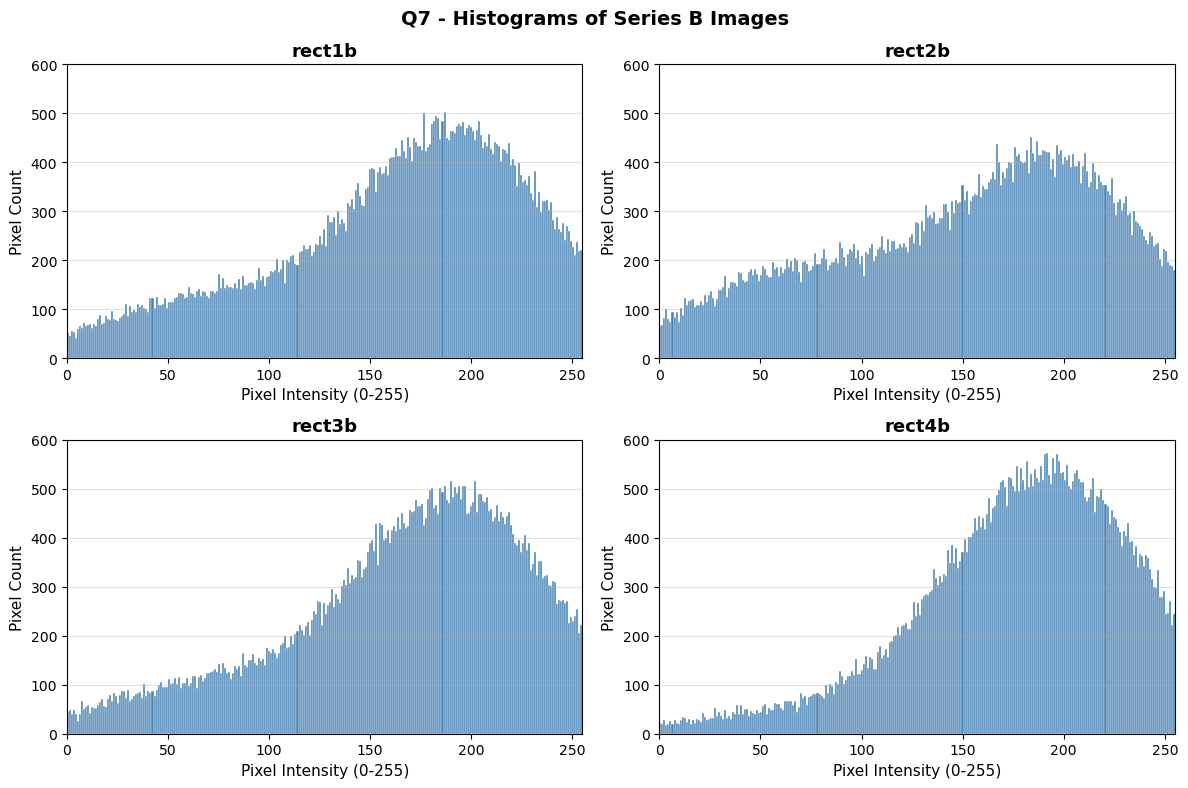

In [108]:
file_names_b = ['rect1b.tif', 'rect2b.tif', 'rect3b.tif', 'rect4b.tif']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for idx, fname in enumerate(file_names_b):
    arr = np.array(dip.ImageRead(fname)).flatten()
    sum_pixels = arr.sum()
    print(f"{fname}: Total pixel intensity sum = {sum_pixels}")
    axes[idx].hist(arr, bins=256, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[idx].set_title(fname.replace('.tif', ''), fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Pixel Intensity (0-255)', fontsize=11)
    axes[idx].set_ylabel('Pixel Count', fontsize=11)
    axes[idx].set_xlim(0, 255)
    axes[idx].set_ylim(0, 600)
    axes[idx].grid(axis='y', alpha=0.4)
fig.suptitle('Q7 - Histograms of Series B Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/q7_b_histograms_seriesB.png', bbox_inches='tight')
plt.show()

rect1c.tif: Total pixel intensity sum = 9458446
rect2c.tif: Total pixel intensity sum = 9099830
rect3c.tif: Total pixel intensity sum = 9563072
rect4c.tif: Total pixel intensity sum = 9871326


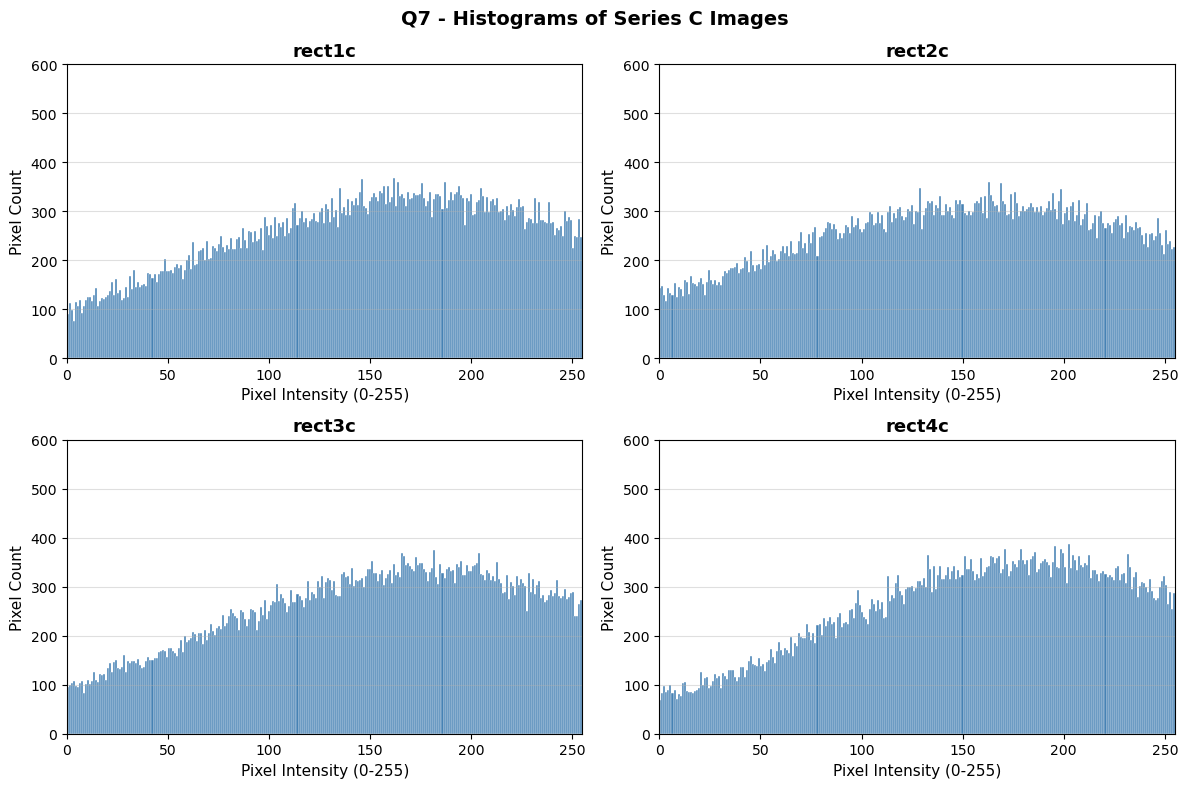

In [110]:
file_names_c = ['rect1c.tif', 'rect2c.tif', 'rect3c.tif', 'rect4c.tif']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for idx, fname in enumerate(file_names_c):
    arr = np.array(dip.ImageRead(fname)).flatten()
    sum_pixels = arr.sum()
    print(f"{fname}: Total pixel intensity sum = {sum_pixels}")
    axes[idx].hist(arr, bins=256, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[idx].set_title(fname.replace('.tif', ''), fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Pixel Intensity (0-255)', fontsize=11)
    axes[idx].set_ylabel('Pixel Count', fontsize=11)
    axes[idx].set_xlim(0, 255)
    axes[idx].set_ylim(0, 600)
    axes[idx].grid(axis='y', alpha=0.4)
fig.suptitle('Q7 - Histograms of Series C Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/q7_c_histograms_seriesC.png', bbox_inches='tight')
plt.show()

Question 8: Parameter tunning

In [ ]:
def find_optimal_filtering(image, true_image):
        #image we test on
        original = dip.ImageRead(image)
        #ground truth or "a" image
        gt= dip.ImageRead(true_image)
        gtresh = ~dip.IsodataThreshold(gt)
        labeled = dip.Label(gtresh, minSize=50)

        #Otain true measurements for the ground truth image
        true_measurement = dip.MeasurementTool.Measure(labeled, gt, ["Size", "Perimeter"])
        area_gt = [true_measurement[obj]['Size'][0] for obj in true_measurement.Objects()]
        perimeter_gt = [true_measurement[obj]['Perimeter'][0] for obj in true_measurement.Objects()]
        
        #benchmark different filters and kernel sizes
        for filter in [ 'Kuwahara', 'MedianFilter','Gauss']:
            for kernel_size in range(3,20, 2): 
                test = original.Copy()
                #running the gaussian filter with default, since different sigmas produce bad results
                if filter == 'Gauss':
                    #gaussian filter in diplib uses sigma and truncation to determine the kernel size, so we convert our kernel size to sigma by dividing by 2 (since the kernel size is 2sigma + 1)
                    kernel_size = kernel_size //2 
                    a = dip.Gauss(test, sigmas=[kernel_size], truncation=1.0)                    
                    
                elif filter == 'Kuwahara':
                    a = dip.Kuwahara(test,kernel = kernel_size) 
                    
                elif filter == 'MedianFilter':
                    a = dip.MedianFilter(test, kernel=  kernel_size)

                #thresholding and labeling
                a = ~dip.IsodataThreshold(a)
                a = dip.Label(a, minSize=50)    
                #new measurements after filtering
                measure_size = dip.MeasurementTool.Measure(a, dip.Image(),["Size", "Perimeter"])            
                area = [measure_size[obj]['Size'][0] for obj in measure_size.Objects()]     
                perimeter = [measure_size[obj]['Perimeter'][0] for obj in measure_size.Objects()]
                # filter changed the object count so we penalize heavily
                if len(area) != len(area_gt):
                    error_area = 1e6
                    error_perimeter = 1e6
                else:
                # compute mean absolute error for area and perimeter
                    error_area = np.mean(np.abs(np.array(area) - np.array(area_gt)))
                    error_perimeter = np.mean(np.abs(np.array(perimeter) - np.array(perimeter_gt)))
                
                print(f"Filter: {filter}, Kernel Size: {kernel_size}, "
                    f"#obj: {len(area)}/{len(area_gt)}, "
                    f"Area Error: {error_area:.2f}, Perimeter Error: {error_perimeter:.2f}")
                            
                    # if filter == 'Gauss' and kernel_size == 7:
                    #     break

In [95]:
#running tests for series B and C
print("─" * 40 + " Optimal Filtering for Series B" + "─" * 40)
print("CASE 3" + "─" * 80)
find_optimal_filtering('rect3b.tif', 'rect3a.tif')
print("CASE 4" + "─" * 80)
find_optimal_filtering('rect4b.tif', 'rect4a.tif')
print("─" * 40 + " Optimal Filtering for Series C" + "─" * 40)
print("CASE 1" + "─" * 80)
find_optimal_filtering('rect1c.tif', 'rect1a.tif')
print("CASE 2" + "─" * 80)
find_optimal_filtering('rect2c.tif', 'rect2a.tif')
print("CASE 3" + "─" * 80)
find_optimal_filtering('rect3c.tif', 'rect3a.tif')
print("CASE 4" + "─" * 80)
find_optimal_filtering('rect4c.tif', 'rect4a.tif')

──────────────────────────────────────── Optimal Filtering for Series B────────────────────────────────────────
CASE 3────────────────────────────────────────────────────────────────────────────────
Filter: Kuwahara, Kernel Size: 3, #obj: 8/8, Area Error: 9.62, Perimeter Error: 3.01
Filter: Kuwahara, Kernel Size: 5, #obj: 8/8, Area Error: 10.38, Perimeter Error: 1.72
Filter: Kuwahara, Kernel Size: 7, #obj: 8/8, Area Error: 16.50, Perimeter Error: 2.92
Filter: Kuwahara, Kernel Size: 9, #obj: 8/8, Area Error: 24.25, Perimeter Error: 5.10
Filter: Kuwahara, Kernel Size: 11, #obj: 8/8, Area Error: 28.25, Perimeter Error: 6.45
Filter: Kuwahara, Kernel Size: 13, #obj: 8/8, Area Error: 35.00, Perimeter Error: 7.95
Filter: Kuwahara, Kernel Size: 15, #obj: 8/8, Area Error: 41.38, Perimeter Error: 9.34
Filter: Kuwahara, Kernel Size: 17, #obj: 8/8, Area Error: 51.50, Perimeter Error: 9.82
Filter: Kuwahara, Kernel Size: 19, #obj: 8/8, Area Error: 58.38, Perimeter Error: 11.69
Filter: MedianFilter, 

It is hard to justify which filter is best, since we only have a simplistic numeric score, that might be flawed in certain extrme occasions (for example meessing up the order of labeled figures). Furthermore the best scores for perimeter rarely align with the best scores for area. Since perimeter is a better aproximator for shape, we will lean on it more during selection.
Based on the results for B-type noise we use Median filter of kernel size 5x5 (Gauss is also a valid choice), while for C-type noise we use Gauss with kernel-size 11x11 (sigma = 5) (however this decision is hardly scientific).


In [96]:
# Series B and C filenames
filenames_b = {
    'rect1b': 'rect1b.tif',
    'rect2b': 'rect2b.tif',
    'rect3b': 'rect3b.tif',
    'rect4b': 'rect4b.tif',
}
filenames_c = {
    'rect1c': 'rect1c.tif',
    'rect2c': 'rect2c.tif',
    'rect3c': 'rect3c.tif',
    'rect4c': 'rect4c.tif',
}

series_b = {name: dip.ImageRead(fname) for name, fname in filenames_b.items()}
series_c = {name: dip.ImageRead(fname) for name, fname in filenames_c.items()}

In [97]:
help(dip.Gauss)

Help on built-in function Gauss in module diplib.PyDIP_bin:

Gauss(...) method of builtins.PyCapsule instance
    Gauss(*args, **kwargs)
    Overloaded function.
    
    1. Gauss(in: diplib.PyDIP_bin.Image, sigmas: list[float] = [1.0], derivativeOrder: list[int] = [0], method: str = 'best', boundaryCondition: list[str] = [], truncation: float = 3.0) -> diplib.PyDIP_bin.Image
    
    Convolution with a Gaussian kernel and its derivatives
    
    2. Gauss(in: diplib.PyDIP_bin.Image, *, out: diplib.PyDIP_bin.Image, sigmas: list[float] = [1.0], derivativeOrder: list[int] = [0], method: str = 'best', boundaryCondition: list[str] = [], truncation: float = 3.0) -> None
    
    Convolution with a Gaussian kernel and its derivatives



Question 9a): Tables of measurements after appropriate filters

In [117]:
results = {}
for name in sorted(series_b):
    img = series_b[name]
    img = dip.MedianFilter(img, kernel=5)
    bin_img = ~dip.IsodataThreshold(img)
    labeled = dip.Label(bin_img, minSize=50)
    msr = dip.MeasurementTool.Measure(labeled, img, ['Size', 'Perimeter'])
    areas  = [msr[obj]['Size'][0]      for obj in msr.Objects()]
    perims = [msr[obj]['Perimeter'][0] for obj in msr.Objects()]
    results[name] = {'areas': areas, 'perims': perims, 'n': len(areas)}

# Combined table
print(f"{'Image':<10} {'Object':>8} {'Area (px²)':>12} {'Perimeter (px)':>16}")
print("=" * 52)
for name in sorted(results):
    r = results[name]
    for i, (a, p) in enumerate(zip(r['areas'], r['perims'])):
        print(f"{name:<10} {i+1:>8} {a:>12.1f} {p:>16.1f}")
    mean_a, mean_p = np.mean(r['areas']), np.mean(r['perims'])
    std_a = np.std(r['areas'],  ddof=1) if r['n'] > 1 else 0.0
    std_p = np.std(r['perims'], ddof=1) if r['n'] > 1 else 0.0
    print(f"{'':10} {'Mean':>8} {mean_a:>12.2f} {mean_p:>16.2f}")
    print(f"{'':10} {'Std Dev':>8} {std_a:>12.2f} {std_p:>16.2f}")
    print("-" * 52)

Image        Object   Area (px²)   Perimeter (px)
rect1b            1      12858.0            470.0
               Mean     12858.00           469.97
            Std Dev         0.00             0.00
----------------------------------------------------
rect2b            1       3202.0            235.2
rect2b            2       3277.0            239.1
rect2b            3       3254.0            233.6
rect2b            4       3256.0            237.1
rect2b            5       3226.0            233.8
rect2b            6       3265.0            238.9
               Mean      3246.67           236.30
            Std Dev        27.64             2.43
----------------------------------------------------
rect3b            1       1305.0            147.1
rect3b            2       1335.0            147.6
rect3b            3       1341.0            149.7
rect3b            4       1281.0            149.6
rect3b            5       1332.0            144.7
rect3b            6       1301.0            

In [99]:
results = {}
for name in sorted(series_c):
    img = series_c[name]
    img = dip.Gauss(img, sigmas=[5.0], truncation=1.0)
    bin_img = ~dip.IsodataThreshold(img)
    labeled = dip.Label(bin_img, minSize=50)
    msr = dip.MeasurementTool.Measure(labeled, img, ['Size', 'Perimeter'])
    areas  = [msr[obj]['Size'][0]      for obj in msr.Objects()]
    perims = [msr[obj]['Perimeter'][0] for obj in msr.Objects()]
    results[name] = {'areas': areas, 'perims': perims, 'n': len(areas)}

# Combined table
print(f"{'Image':<10} {'Object':>8} {'Area (px²)':>12} {'Perimeter (px)':>16}")
print("=" * 52)
for name in sorted(results):
    r = results[name]
    for i, (a, p) in enumerate(zip(r['areas'], r['perims'])):
        print(f"{name:<10} {i+1:>8} {a:>12.1f} {p:>16.1f}")
    mean_a, mean_p = np.mean(r['areas']), np.mean(r['perims'])
    std_a = np.std(r['areas'],  ddof=1) if r['n'] > 1 else 0.0
    std_p = np.std(r['perims'], ddof=1) if r['n'] > 1 else 0.0
    print(f"{'':10} {'Mean':>8} {mean_a:>12.2f} {mean_p:>16.2f}")
    print(f"{'':10} {'Std Dev':>8} {std_a:>12.2f} {std_p:>16.2f}")
    print("-" * 52)

Image        Object   Area (px²)   Perimeter (px)
rect1c            1      12819.0            485.2
               Mean     12819.00           485.17
            Std Dev         0.00             0.00
----------------------------------------------------
rect2c            1       3233.0            232.8
rect2c            2       3307.0            235.8
rect2c            3       3241.0            231.8
rect2c            4       3319.0            237.6
rect2c            5       3267.0            239.2
rect2c            6       3274.0            233.3
               Mean      3273.50           235.09
            Std Dev        34.44             2.96
----------------------------------------------------
rect3c            1       1331.0            146.7
rect3c            2       1350.0            149.7
rect3c            3       1382.0            148.9
rect3c            4       1356.0            148.8
rect3c            5       1358.0            149.8
rect3c            6       1385.0            

Question 9b): We chose to test out the following 4 filters: Gauss (kernel size of 3x3). Median and Kuwahara

<class 'diplib.PyDIP_bin.Image'> <class 'diplib.PyDIP_bin.Image'>
12858.0 469.97159265358977 0.0 0.0


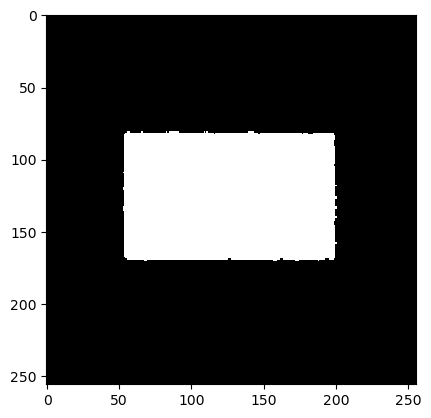

<class 'diplib.PyDIP_bin.Image'> <class 'diplib.PyDIP_bin.Image'>
3246.6666666666665 236.3035926535898 25.230052626888348 2.2208680735244144


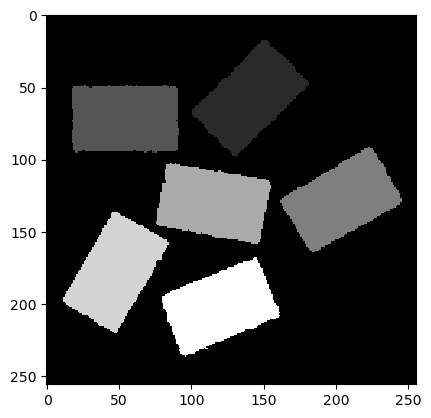

<class 'diplib.PyDIP_bin.Image'> <class 'diplib.PyDIP_bin.Image'>
1317.5 147.76371765358977 29.24038303442689 1.682893225779636


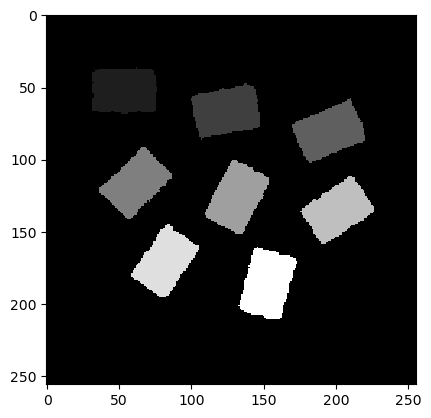

<class 'diplib.PyDIP_bin.Image'> <class 'diplib.PyDIP_bin.Image'>
479.5 91.1993926535898 11.342398335449166 1.689512047900221


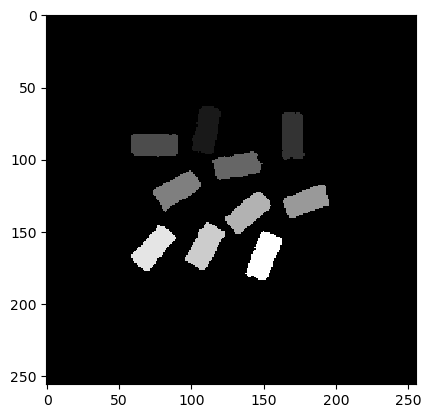

In [100]:
file_names_a = ['rect1b.tif', 'rect2b.tif', 'rect3b.tif',"rect4b.tif" ]
for image in file_names_a:

    a = dip.ImageRead(image)
    a = dip.MedianFilter(a, kernel=5)
    #number_th = dip.IsodataThreshold(hist)
    #a_array = np.asarray(a)
    threshold = ~dip.IsodataThreshold(a)
    
    labeled = dip.Label(threshold,minSize=100)
    labeled_array= np.asanyarray(labeled)
    #print(np.max(labeled_array))  
    print(type(labeled),type(a))
    #a=a>number_t1
    measure_size = dip.MeasurementTool.Measure(labeled,a,["Size"])
    measure_perimeter = dip.MeasurementTool.Measure(labeled,a,["Perimeter"]) 
    size_array = np.asarray(measure_size)

    perimeter_array = np.asanyarray(measure_perimeter)

    #calculate average perimeters
    mean_perimeter = np.mean(perimeter_array)

    #
    std_perimeter = np.std(perimeter_array)

    
    mean_size = np.mean(size_array)
    std_size = np.std(size_array)
    print (mean_size,mean_perimeter,std_size,std_perimeter)
    labeled.Show()
    

12819.0 485.1665926535898 0.0 0.0


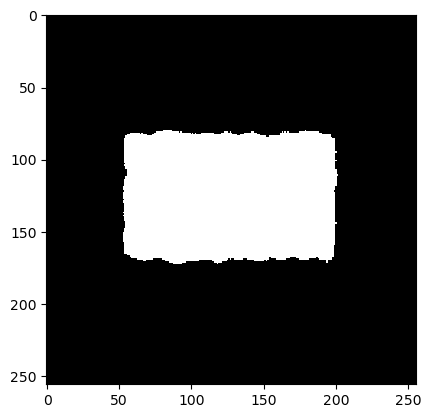

3273.5 235.09209265358982 31.441745074555474 2.698448983521218


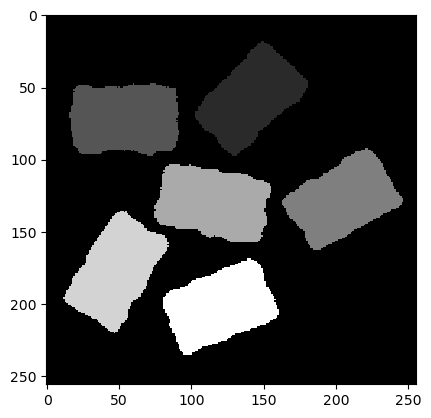

1357.75 148.44434265358979 29.64688010567048 2.9897839282295924


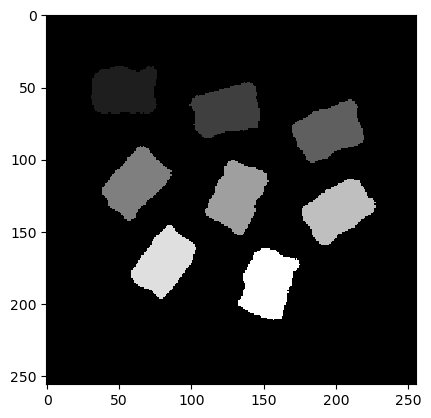

542.2 95.41809265358981 15.772127313713897 3.5789769278384576


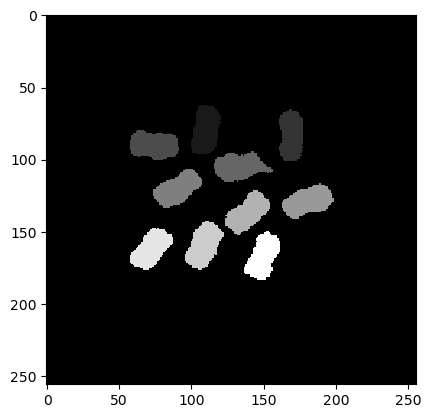

In [101]:
file_names_a = ['rect1c.tif', 'rect2c.tif', 'rect3c.tif',"rect4c.tif" ]
for image in file_names_a:

    a = dip.ImageRead(image)
    a = dip.Gauss(a, sigmas=[5.0], truncation=1.0)
    #number_th = dip.IsodataThreshold(hist)
    #a_array = np.asarray(a)
    threshold = ~dip.IsodataThreshold(a)

    labeled = dip.Label(threshold,minSize=100)
    labeled_array= np.asanyarray(labeled)
    #print(np.max(labeled_array))  

    #a=a>number_t1
    measure_size = dip.MeasurementTool.Measure(labeled,a,["Size"])
    measure_perimeter = dip.MeasurementTool.Measure(labeled,a,["Perimeter"]) 
    size_array = np.asarray(measure_size)

    perimeter_array = np.asanyarray(measure_perimeter)

    #calculate average perimeters
    mean_perimeter = np.mean(perimeter_array)

    #
    std_perimeter = np.std(perimeter_array)

    
    mean_size = np.mean(size_array)
    std_size = np.std(size_array)
    print (mean_size,mean_perimeter,std_size,std_perimeter)
    labeled.Show()

Question 9b):

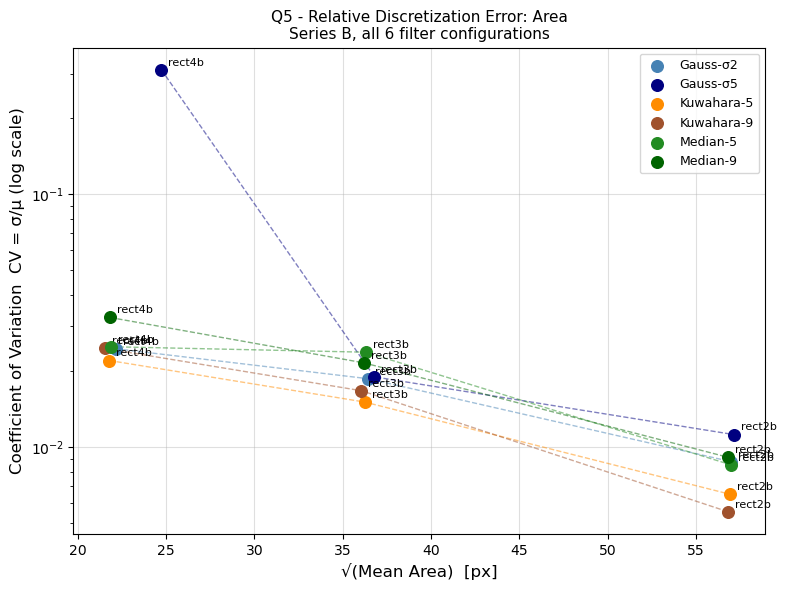

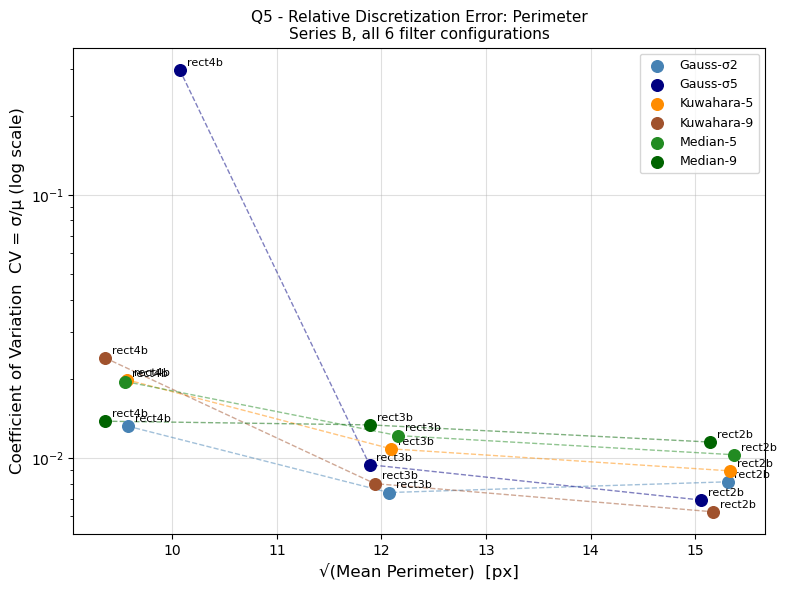

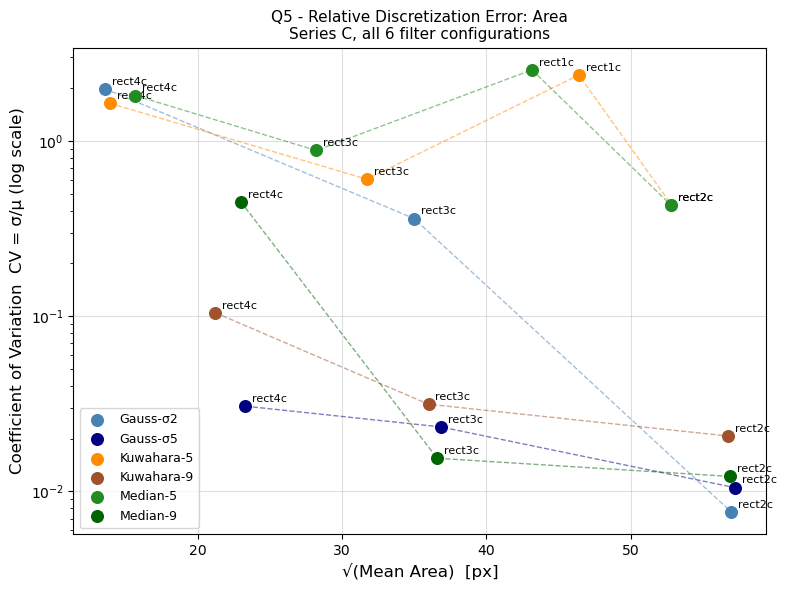

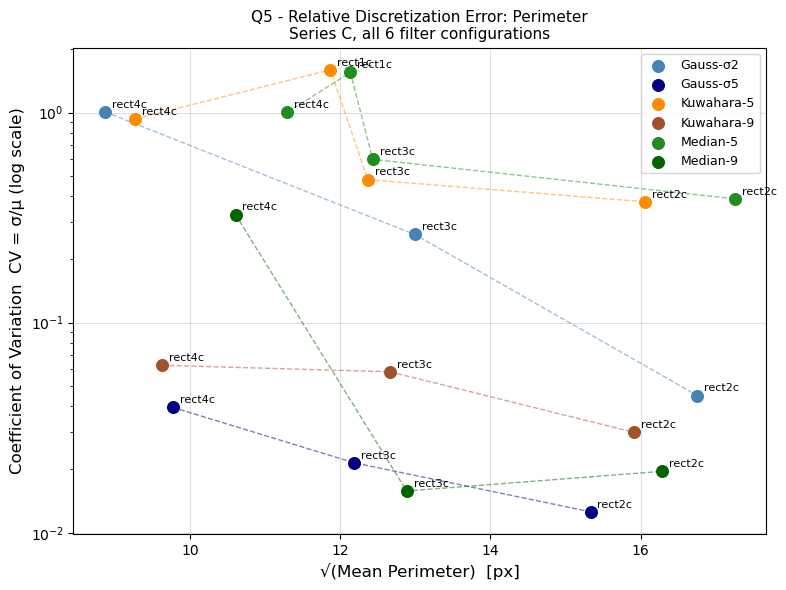

In [102]:
#a list of string, callable pairs for the filters to apply to each image in series B and C
filters = [
    ('Gauss-σ2',   lambda im: dip.Gauss(im, sigmas=[2.0], truncation=1.0)),
    ('Gauss-σ5',   lambda im: dip.Gauss(im, sigmas=[5.0], truncation=1.0)),
    ('Kuwahara-5', lambda im: dip.Kuwahara(im, kernel=5)),
    ('Kuwahara-9', lambda im: dip.Kuwahara(im, kernel=9)),
    ('Median-5',   lambda im: dip.MedianFilter(im, kernel=5)),
    ('Median-9',   lambda im: dip.MedianFilter(im, kernel=9)),
]
colors = ['steelblue', 'navy', 'darkorange', 'sienna', 'forestgreen', 'darkgreen']

def measure_series(series, filt):
    out = {}
    #apply the filter and measure each image in the series
    for name in sorted(series):
        img = filt(series[name])
        bin_img = ~dip.IsodataThreshold(img)
        labeled = dip.Label(bin_img, minSize=50)
        msr = dip.MeasurementTool.Measure(labeled, img, ['Size', 'Perimeter'])
        #save areas and perimeters in the output dictionary
        out[name] = {
            'areas':  [msr[o]['Size'][0]      for o in msr.Objects()],
            'perims': [msr[o]['Perimeter'][0] for o in msr.Objects()],
        }
        out[name]['n'] = len(out[name]['areas'])
    return out

def plot_overlay(all_results, metric, label, series_tag, fname):
    key = 'areas' if metric == 'area' else 'perims'
    fig, ax = plt.subplots(figsize=(8, 6))
    for (filt_name, _), color, results in zip(filters, colors, all_results):
        valid = [n for n in sorted(results) if results[n]['n'] > 1]
        if not valid:
            continue
        means = np.array([np.mean(results[n][key]) for n in valid])
        stds  = np.array([np.std(results[n][key], ddof=1) for n in valid])
        x = np.sqrt(means)
        y = stds / means

        order = np.argsort(x)
        x, y = x[order], y[order]
        valid = [valid[i] for i in order]

        ax.plot(x, y, '--', color=color, alpha=0.5, linewidth=1, zorder=2)
        ax.scatter(x, y, color=color, s=70, label=filt_name, zorder=3)
        for i, n in enumerate(valid):
            ax.annotate(n, (x[i], y[i]),
                        textcoords='offset points', xytext=(5, 3), fontsize=8)
    ax.set_xlabel(f'√(Mean {label})  [px]', fontsize=12)
    ax.set_ylabel('Coefficient of Variation  CV = σ/μ (log scale)', fontsize=12)
    ax.set_title(f'Q5 - Relative Discretization Error: {label}\n'
                 f'Series {series_tag}, all 6 filter configurations', fontsize=11)
    ax.grid(alpha=0.4)
    ax.legend(fontsize=9)
    ax.set_yscale('log')
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

# Apply all filters to both series and plot results
for series, tag in [(series_b, 'B'), (series_c, 'C')]:
    all_results = [measure_series(series, fn) for _, fn in filters]
    plot_overlay(all_results, 'area',      'Area',      tag,
                 f'output/q9_area_series{tag}.png')
    plot_overlay(all_results, 'perimeter', 'Perimeter', tag,
                 f'output/q9_perim_series{tag}.png')

Question 12

In [103]:
#tables of SNR w/o filters on whole iamges
for series, tag in [(series_a, 'A'), (series_b, 'B'), (series_c, 'C')]: 
    for img in sorted(series):
        arr = np.asanyarray(series[img])
        signal = np.mean(arr)
        noise = np.std(arr)
        snr = signal / noise if noise > 0 else float('inf')
        print(f"{tag} - {img}: SNR = {snr:.2f}")

A - rect1a: SNR = 3.28
A - rect2a: SNR = 2.63
A - rect3a: SNR = 3.64
A - rect4a: SNR = 5.46
B - rect1b: SNR = 2.66
B - rect2b: SNR = 2.30
B - rect3b: SNR = 2.83
B - rect4b: SNR = 3.43
C - rect1c: SNR = 2.16
C - rect2c: SNR = 2.04
C - rect3c: SNR = 2.20
C - rect4c: SNR = 2.33


We again perform the becnhmark the all algorithms

In [104]:
for filter_name, filter_fn in filters:
    print(f"\n── SNR after applying {filter_name} ──────────────────────────────")
    for series, tag in [(series_a, 'A'), (series_b, 'B'), (series_c, 'C')]:
        for img in sorted(series):
            filtered = filter_fn(series[img])
            arr = np.asanyarray(filtered)
            signal = np.mean(arr)
            noise = np.std(arr)
            snr = signal / noise if noise > 0 else float('inf')
            print(f"{tag} - {img} : SNR = {snr:.2f}")


── SNR after applying Gauss-σ2 ──────────────────────────────
A - rect1a : SNR = 3.34
A - rect2a : SNR = 2.74
A - rect3a : SNR = 3.83
A - rect4a : SNR = 5.92
B - rect1b : SNR = 3.71
B - rect2b : SNR = 3.09
B - rect3b : SNR = 4.22
B - rect4b : SNR = 6.29
C - rect1c : SNR = 5.82
C - rect2c : SNR = 5.04
C - rect3c : SNR = 6.29
C - rect4c : SNR = 8.10

── SNR after applying Gauss-σ5 ──────────────────────────────
A - rect1a : SNR = 3.41
A - rect2a : SNR = 2.88
A - rect3a : SNR = 4.10
A - rect4a : SNR = 6.65
B - rect1b : SNR = 3.86
B - rect2b : SNR = 3.30
B - rect3b : SNR = 4.62
B - rect4b : SNR = 7.33
C - rect1c : SNR = 6.75
C - rect2c : SNR = 5.86
C - rect3c : SNR = 7.84
C - rect4c : SNR = 11.57

── SNR after applying Kuwahara-5 ──────────────────────────────
A - rect1a : SNR = 3.29
A - rect2a : SNR = 2.63
A - rect3a : SNR = 3.64
A - rect4a : SNR = 5.49
B - rect1b : SNR = 3.44
B - rect2b : SNR = 2.81
B - rect3b : SNR = 3.83
B - rect4b : SNR = 5.59
C - rect1c : SNR = 4.79
C - rect2c : SNR

2D Scalar image:
    data type:      SFLOAT
    sizes:          {256, 256}
    strides:        {1, 256}, tensor stride 1
    data pointer:   00000208132AC060 (shared among 1 images)
    origin pointer: 00000208132AC060



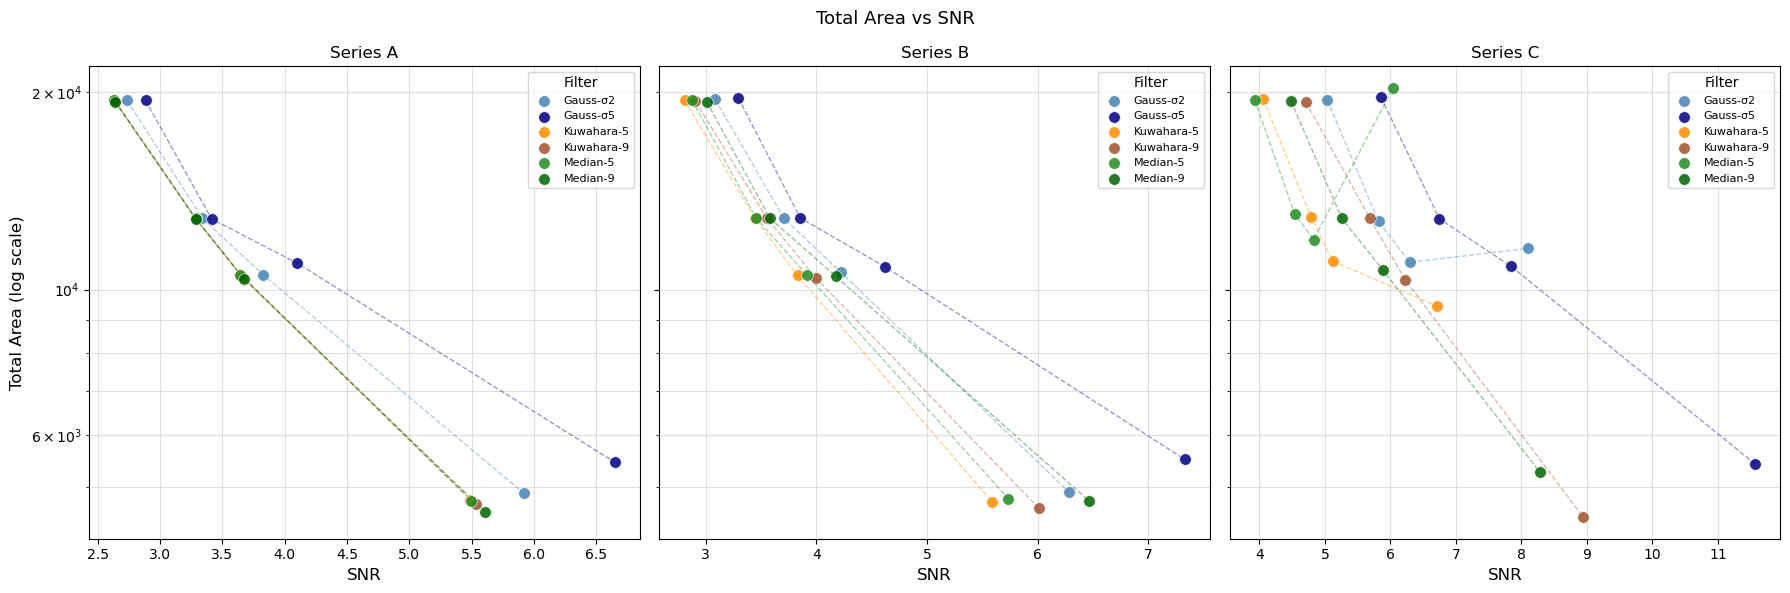

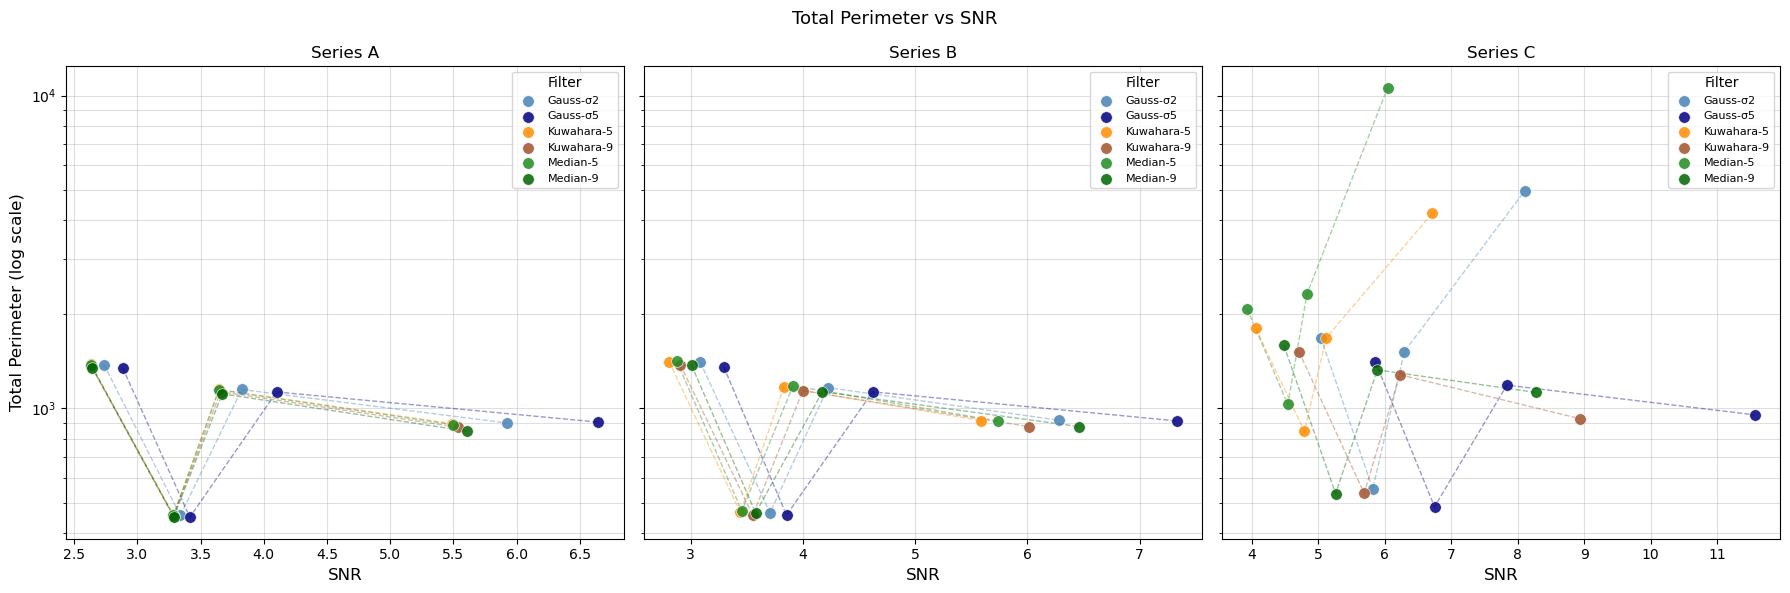

In [105]:
filter_colors =dict(zip(['Gauss-σ2', 'Gauss-σ5', 'Kuwahara-5', 'Kuwahara-9', 'Median-5', 'Median-9'], colors))
series_marker = {'A': 'o', 'B': 'o', 'C': 'o'}
print(a)
results = []
for filter_name, filter_fn in filters:
   
    for series, tag in [(series_a, 'A'), (series_b, 'B'), (series_c, 'C')]:
        for img in sorted(series):
            filtered = filter_fn(series[img])
            arr = np.asanyarray(filtered)
            signal = np.mean(arr)
            noise = np.std(arr)
            snr = signal / noise if noise > 0 else float('inf')
            
            measure_perimeter = np.asanyarray(dip.MeasurementTool.Measure(dip.Label(~dip.IsodataThreshold(filtered), minSize=50), filtered, ["Perimeter"]))
            
            measure_size = np.asanyarray(dip.MeasurementTool.Measure(dip.Label(~dip.IsodataThreshold(filtered), minSize=50), filtered, ["Size"]))
            total_perimeter = np.sum(measure_perimeter)
            total_area = np.sum(measure_size)
            results.append((filter_name, tag, img, snr, total_area, total_perimeter))



def plot_snr_vs(metric_idx, label, fname):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    for ax, tag in zip(axes, ['A', 'B', 'C']):
        for filter_name in filter_colors:
            subset = [r for r in results if r[0] == filter_name and r[1] == tag]
            if not subset:
                continue
            xs = np.array([r[3] for r in subset])
            ys = np.array([r[metric_idx] for r in subset])
            order = np.argsort(xs)
            xs, ys = xs[order], ys[order]

            ax.plot(xs, ys, '--',
                    color=filter_colors[filter_name],
                    alpha=0.4, linewidth=1, zorder=2)
            ax.scatter(xs, ys,
                       color=filter_colors[filter_name],
                       marker=series_marker[tag],
                       s=70, alpha=0.85, edgecolor='white', linewidth=0.5,
                       label=filter_name, zorder=3)
        ax.set_yscale('log')
        ax.set_xlabel('SNR', fontsize=12)
        if ax is axes[0]:
            ax.set_ylabel(f'Total {label} (log scale)', fontsize=12)
        ax.set_title(f'Series {tag}', fontsize=12)
        ax.grid(alpha=0.4, which='both')
        ax.legend(fontsize=8, title='Filter', loc='best')
    fig.suptitle(f'Total {label} vs SNR', fontsize=13)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

plot_snr_vs(4, 'Area',      'output/snr_vs_area.png')
plot_snr_vs(5, 'Perimeter', 'output/snr_vs_perimeter.png')

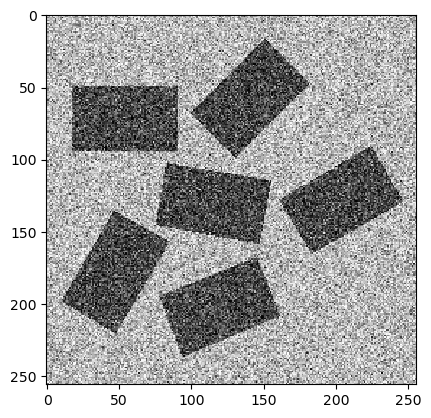

KeyError: 'rect54b'

In [115]:
img = series_b['rect2b']
img.Show()
img = series_b['rect54b']
img.Show(   )